In [6]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
import random
import numpy.linalg as la

 Ejemplo de una mtz de varianzas y covarianzas entre variables $\Sigma$:

In [ ]:
x=np.array([1,2,3,4,5,6,7,8,9])
y=np.array([9,8,7,6,5,4,3,2,1])
x,y

(array([1, 2, 3, 4, 5, 6, 7, 8, 9]), array([9, 8, 7, 6, 5, 4, 3, 2, 1]))

In [ ]:
Cov=np.cov(x,y)
Cov

array([[ 7.5, -7.5],
       [-7.5,  7.5]])

In [ ]:
np.corrcoef(x,y)

array([[ 1., -1.],
       [-1.,  1.]])

### Análisis de Componentes Principales

El Análisis de Componentes Principales (PCA en inglés) es una técnica estadística utilizada para simplificar la complejidad en conjuntos de datos de alta dimensión, reduciendo la cantidad de variables (mediante **combinaciones lineales**), pero al mismo tiempo conservando la mayor cantidad posible de información original.

Se utiliza en áreas como reducción de dimensiones, visualización de datos, y en la identificación de patrones y estructuras subyacentes en los datos.

#### Intuición detrás de PCA
El objetivo principal de PCA es identificar las direcciones (o componentes principales) a lo largo de las cuales varían los datos. La idea es transformar las variables originales en un nuevo conjunto de variables, los componentes principales, que son **ortogonales (independientes) entre sí** y que capturan la **mayor parte de la variabilidad presente en los datos originales.**

#### Ejemplo Práctico

In [ ]:
#pip uninstall matplotlib matplotlib-inline -y

In [ ]:
#pip install matplotlib matplotlib-inline

In [ ]:
#pip install --upgrade matplotlib

In [9]:
#pip install pca

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 44.9 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.8.0
    Uninstalling matplotlib-3.8.0:
      Successfully uninstalled matplotlib-3.8.0


In [10]:
from pca import pca

In [14]:
df=pd.read_csv("municipios.csv", encoding="latin-1")
df

,Clave_mun,longitud,latitud,altitud,totreg,ingtoper,Censo_y_edu,Censo_y_salud,Censo_y_ss,Censo_y_cv,...,Enigh_y_edu,Enigh_y_salud,Enigh_y_ss,Enigh_y_cv,Enigh_y_sbv,Enigh_y_ali2,Enigh_y_ing,Nb_mun,Population,Gini_coef
0,1,970033,193513,2020,7503,2550526,0.3675,0.9230,0.9152,0.6040,...,0.342191,0.550816,0.905494,0.288390,0.189470,0.220319,1.11925,Acajete,7117,0.438707
1,2,965031,194150,1740,2558,1532146,0.3753,0.9629,0.9582,0.1443,...,0.306714,0.480169,0.959326,0.089450,0.126147,0.305756,1.50103,Acatlán,2983,0.370577
2,3,945448,175654,100,77737,55300000,0.2782,0.7804,0.7487,0.4183,...,0.274846,0.261125,0.744406,0.292389,0.561117,0.229383,1.62541,Acayucan,91089,0.430602
3,4,963709,193013,260,39308,26100000,0.4237,0.6479,0.6382,0.3576,...,0.327091,0.489681,0.725265,0.087810,0.117200,0.217913,1.67230,Actopan,44150,0.394426
4,5,954624,183022,10,5017,5645295,0.3889,0.6303,0.6418,0.3117,...,0.314982,0.074335,0.769867,0.142259,0.542609,0.297072,1.57418,Acula,4630,0.396407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,206,942431,180416,10,27166,37700000,0.1532,0.3142,0.2910,0.2195,...,0.150538,0.127432,0.391946,0.173920,0.281291,0.210532,3.44725,Nanchital de Lázaro Cárdenas del Río,30273,0.411311
206,207,960806,181426,40,44167,38800000,0.3080,0.4747,0.5123,0.3005,...,0.304615,0.418508,0.671671,0.222029,0.486824,0.241076,1.74084,Tres Valles,46135,0.410793
207,208,954441,182226,5,22857,17900000,0.3337,0.3759,0.3651,0.1676,...,0.312677,0.207699,0.486485,0.114194,0.359560,0.260709,2.19711,Carlos A. Carrillo,28012,0.371326
208,209,944536,181442,120,12463,2484772,0.3661,0.9606,0.9528,0.8679,...,0.414019,0.685949,0.921913,0.478270,0.664580,0.266093,0.92271,Tatahuicapan de Juárez,13978,0.454473


In [15]:
X=df.iloc[:,6:14]
X

,Censo_y_edu,Censo_y_salud,Censo_y_ss,Censo_y_cv,Censo_y_sbv,Censo_y_ali,Censo_y_ing,Censo_y_esco
0,0.3675,0.9230,0.9152,0.6040,0.7520,0.1801,0.3399,3.3900
1,0.3753,0.9629,0.9582,0.1443,0.0696,0.0797,0.5990,3.5813
2,0.2782,0.7804,0.7487,0.4183,0.5256,0.2064,0.7114,4.7598
3,0.4237,0.6479,0.6382,0.3576,0.3437,0.0509,0.6640,3.9212
4,0.3889,0.6303,0.6418,0.3117,0.8597,0.1023,1.1252,3.8657
...,...,...,...,...,...,...,...,...
205,0.1532,0.3142,0.2910,0.2195,0.2728,0.0377,1.3878,6.0991
206,0.3080,0.4747,0.5123,0.3005,0.5390,0.0668,0.8785,4.4282
207,0.3337,0.3759,0.3651,0.1676,0.3195,0.0515,0.7831,4.7655
208,0.3661,0.9606,0.9528,0.8679,0.8616,0.4877,0.1994,2.7895


In [16]:
X.describe()

,Censo_y_edu,Censo_y_salud,Censo_y_ss,Censo_y_cv,Censo_y_sbv,Censo_y_ali,Censo_y_ing,Censo_y_esco
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,0.332795,0.787425,0.782759,0.542923,0.640693,0.236819,0.553623,3.846106
std,0.074569,0.176197,0.179754,0.224150,0.243505,0.180866,0.336304,1.149643
min,0.135900,0.314200,0.291000,0.117800,0.069600,0.013700,0.102100,0.838400
25%,0.290500,0.663850,0.643675,0.348925,0.456775,0.100800,0.310400,3.142575
50%,0.345000,0.841100,0.845250,0.535500,0.679150,0.177350,0.490800,3.767300
75%,0.380325,0.928675,0.928800,0.727150,0.859300,0.314325,0.693475,4.433100
max,0.503700,0.990600,0.996200,0.971700,0.997700,0.948300,2.555400,7.110600


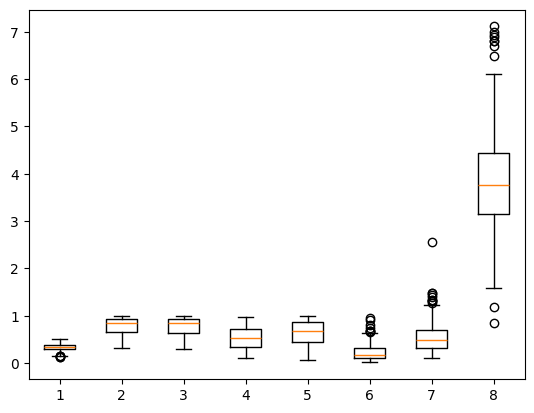

In [17]:
plt.boxplot(X);

# Rango Intercuartilico (IQR)
# IQR= Q3-Q1
# Outlier Theshold
# Outlier Abajo: Q1-1.5xIQR
# Outlier Arriba: Q3+1.5xIQR

<Axes: ylabel='Censo_y_ing'>

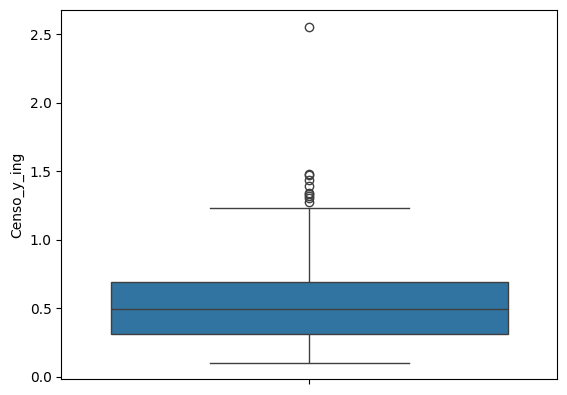

In [18]:
import seaborn as sns
sns.boxplot(X["Censo_y_ing"])

In [19]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler().fit(X) # (x-media)/desv.estándar
X_norm=scaler.transform(X) # efectúa la estandarización

X_norm

# En PCA se aconseja estandarizar para quitae el efecto de diferentes escalares en sus columnas

array([[ 0.46651847,  0.77129298,  0.73855219, ..., -0.31434597,
        -0.63702275, -0.39768485],
       [ 0.57136991,  0.99828569,  0.97834014, ..., -0.87077871,
         0.1352512 , -0.23088775],
       [-0.73389603, -0.03996415, -0.18992905, ..., -0.16858719,
         0.47027085,  0.79666263],
       ...,
       [ 0.01216225, -2.34118093, -2.32906062, ..., -1.02706759,
         0.68398   ,  0.80163254],
       [ 0.44769899,  0.9852009 ,  0.94822724, ...,  1.39042208,
        -1.05579732, -0.92126907],
       [ 0.5055017 ,  1.02331747,  0.99953071, ...,  1.00468783,
        -0.97770555, -0.71305607]])

In [20]:
X_norm=pd.DataFrame(X_norm)
X_norm.columns=X.columns
X_norm

,Censo_y_edu,Censo_y_salud,Censo_y_ss,Censo_y_cv,Censo_y_sbv,Censo_y_ali,Censo_y_ing,Censo_y_esco
0,0.466518,0.771293,0.738552,0.273132,0.458197,-0.314346,-0.637023,-0.397685
1,0.571370,0.998286,0.978340,-1.782627,-2.350908,-0.870779,0.135251,-0.230888
2,-0.733896,-0.039964,-0.189929,-0.557310,-0.473781,-0.168587,0.470271,0.796663
3,1.221987,-0.793762,-0.806128,-0.828758,-1.222573,-1.030393,0.328990,0.065476
4,0.754188,-0.893889,-0.786053,-1.034021,0.901544,-0.745526,1.703644,0.017085
...,...,...,...,...,...,...,...,...
205,-2.414207,-2.692195,-2.742277,-1.446336,-1.514433,-1.103549,2.486350,1.964417
206,-0.333310,-1.779104,-1.508205,-1.084107,-0.418619,-0.942273,0.968329,0.507536
207,0.012162,-2.341181,-2.329061,-1.678430,-1.322193,-1.027068,0.683980,0.801633
208,0.447699,0.985201,0.948227,1.453282,0.909366,1.390422,-1.055797,-0.921269


In [21]:
X_norm.describe()

,Censo_y_edu,Censo_y_salud,Censo_y_ss,Censo_y_cv,Censo_y_sbv,Censo_y_ali,Censo_y_ing,Censo_y_esco
count,2.100000e+02,2.100000e+02,2.100000e+02,2.100000e+02,2.100000e+02,2.100000e+02,2.100000e+02,2.100000e+02
mean,1.036208e-16,3.383537e-16,-3.933362e-16,9.304726e-17,-1.268826e-16,8.458842e-18,1.649474e-16,6.344132e-17
std,1.002389e+00,1.002389e+00,1.002389e+00,1.002389e+00,1.002389e+00,1.002389e+00,1.002389e+00,1.002389e+00
min,-2.646763e+00,-2.692195e+00,-2.742277e+00,-1.901134e+00,-2.350908e+00,-1.236561e+00,-1.345810e+00,-2.622460e+00
25%,-5.685534e-01,-7.030218e-01,-7.755972e-01,-8.675524e-01,-7.570991e-01,-7.538392e-01,-7.249505e-01,-6.134181e-01
50%,1.640624e-01,3.053606e-01,3.484785e-01,-3.319684e-02,1.583091e-01,-3.295869e-01,-1.872499e-01,-6.871179e-02
75%,6.389184e-01,8.035783e-01,8.143921e-01,8.238539e-01,8.998978e-01,4.295503e-01,4.168436e-01,5.118084e-01
max,2.297386e+00,1.155872e+00,1.190246e+00,1.917471e+00,1.469622e+00,3.943140e+00,5.966501e+00,2.846358e+00


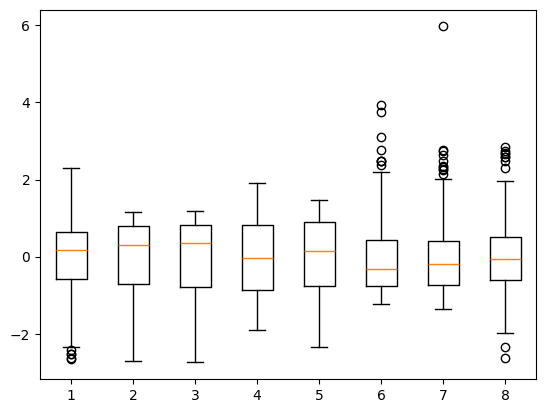

In [22]:
plt.boxplot(X_norm);

In [23]:
pca_model=pca(n_components=4)

In [24]:
pca_model

[pca] >Extracting column labels from dataframe.
[pca] >Extracting row labels from dataframe.
[pca] >The PCA reduction is performed on the [8] columns of the input dataframe.
[pca] >Fit using PCA.
[pca] >Compute loadings and PCs.
[pca] >Compute explained variance.
[pca] >Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[4]
[pca] >Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[pca] >Outlier detection using SPE/DmodX with n_std=[3]


[scatterd] >INFO> Create scatterplot
[scatterd] >INFO> Create scatterplot


[scatterd]> WARNING use the standardized verbose status. The status [1-6] will be deprecated in future versions.
[pca]> [WARNING]: De parameter <label> is deprecated and will not be supported in future version.
[pca] >Plot PC1 vs PC2 with loadings.
[scatterd]> WARNING use the standardized verbose status. The status [1-6] will be deprecated in future versions.


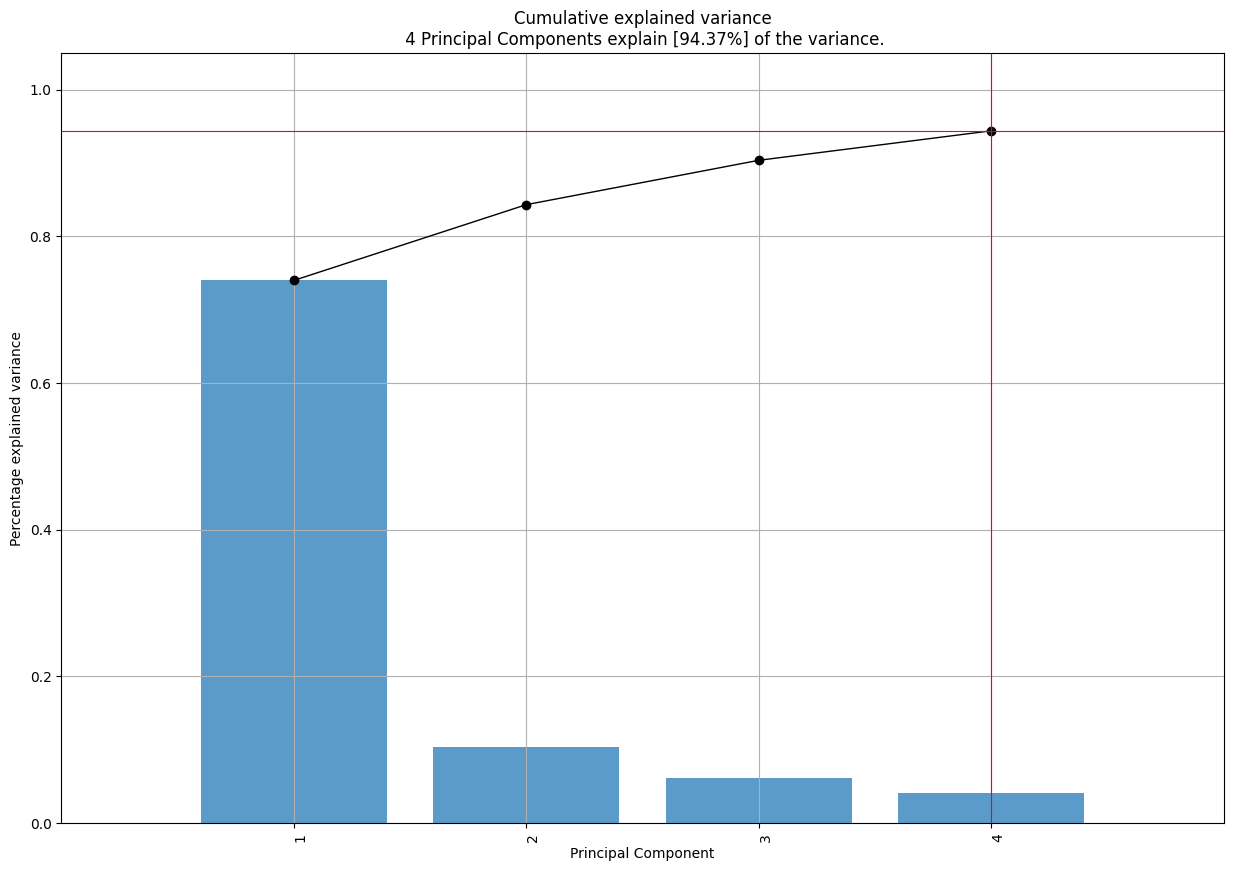

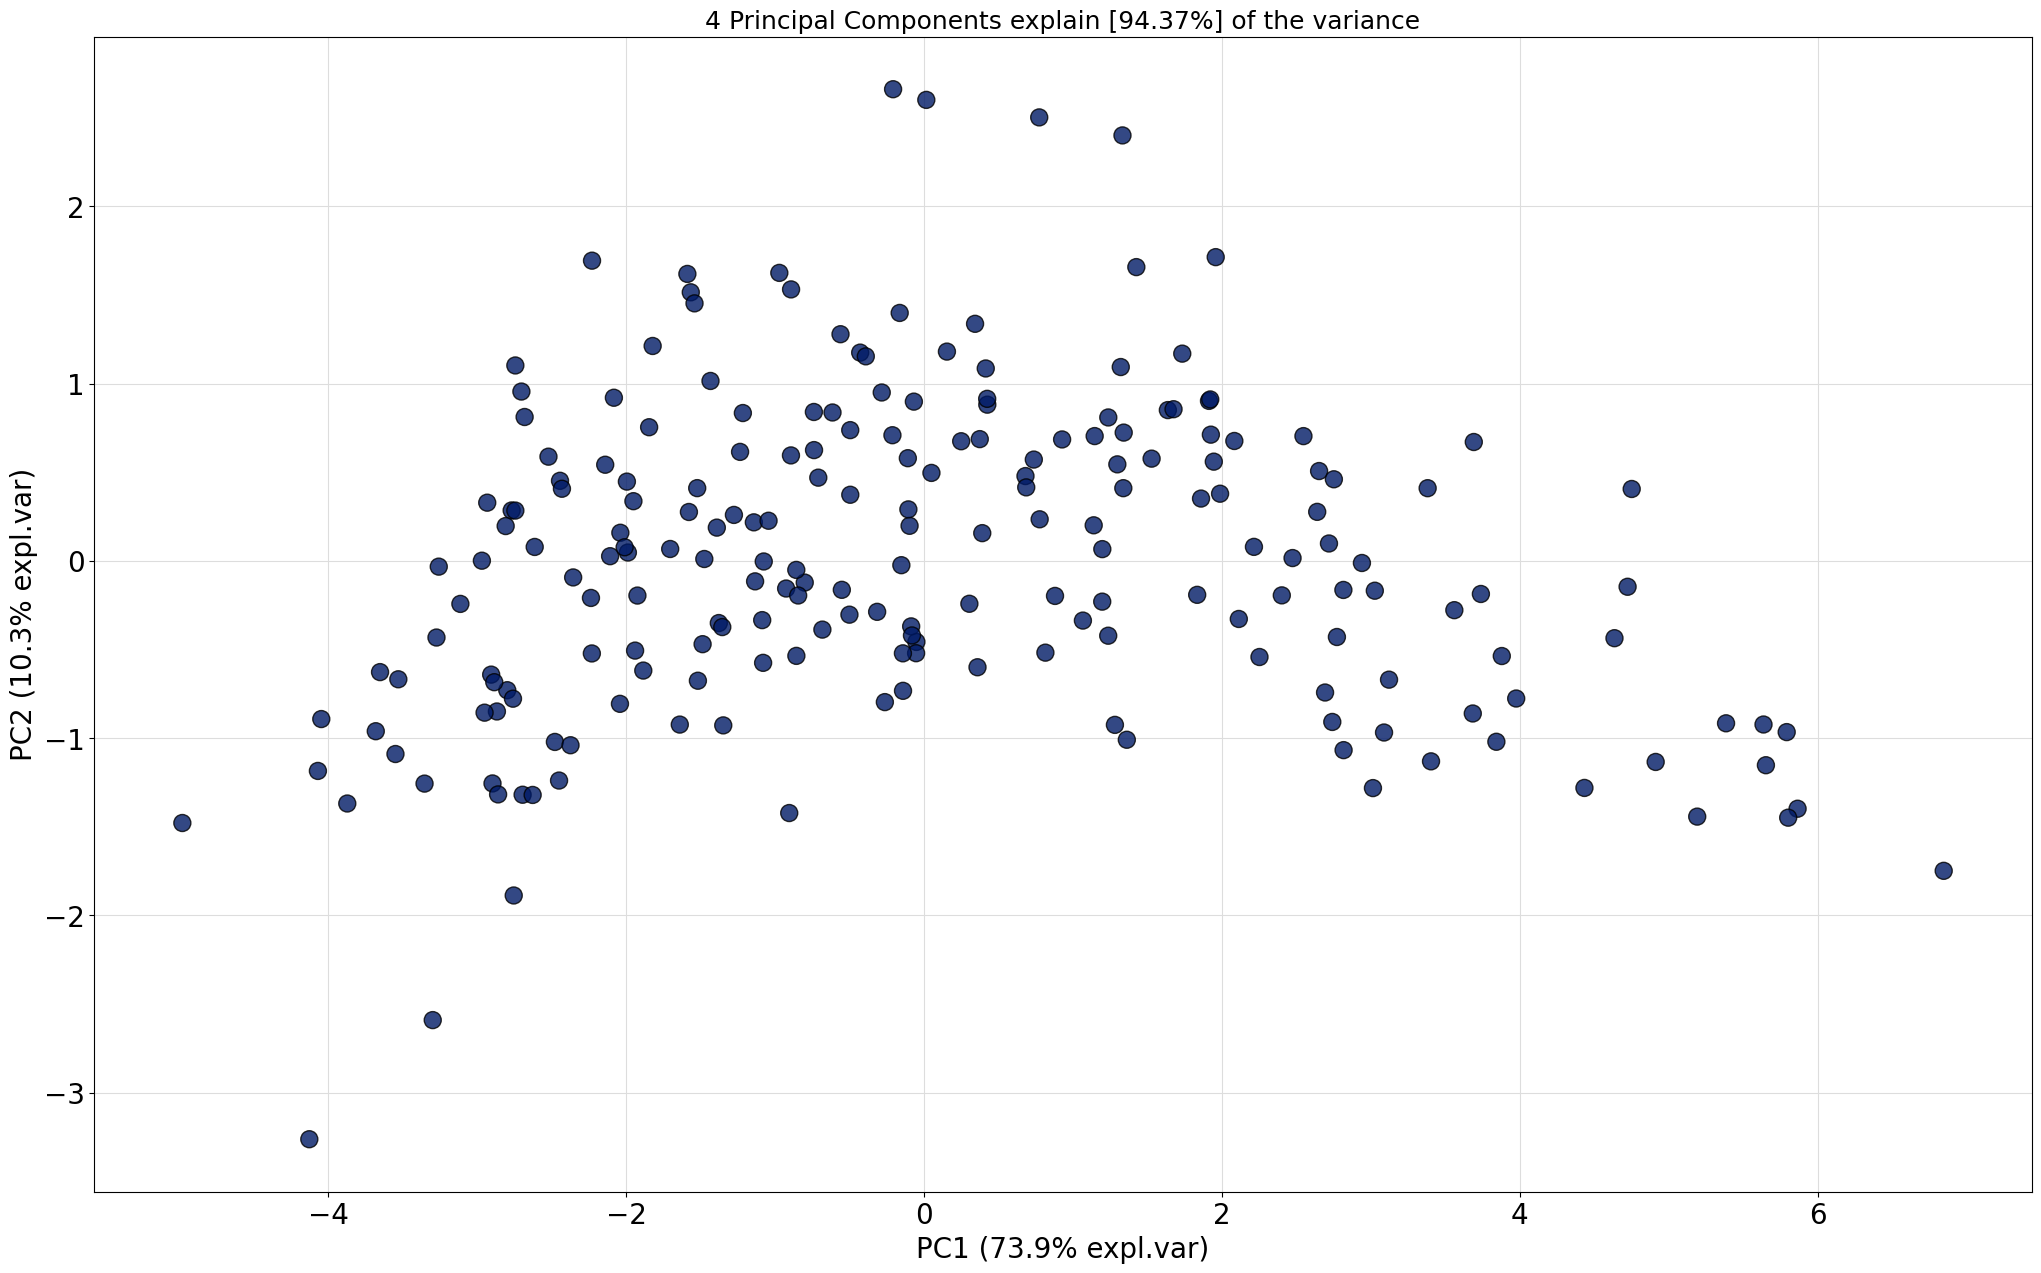

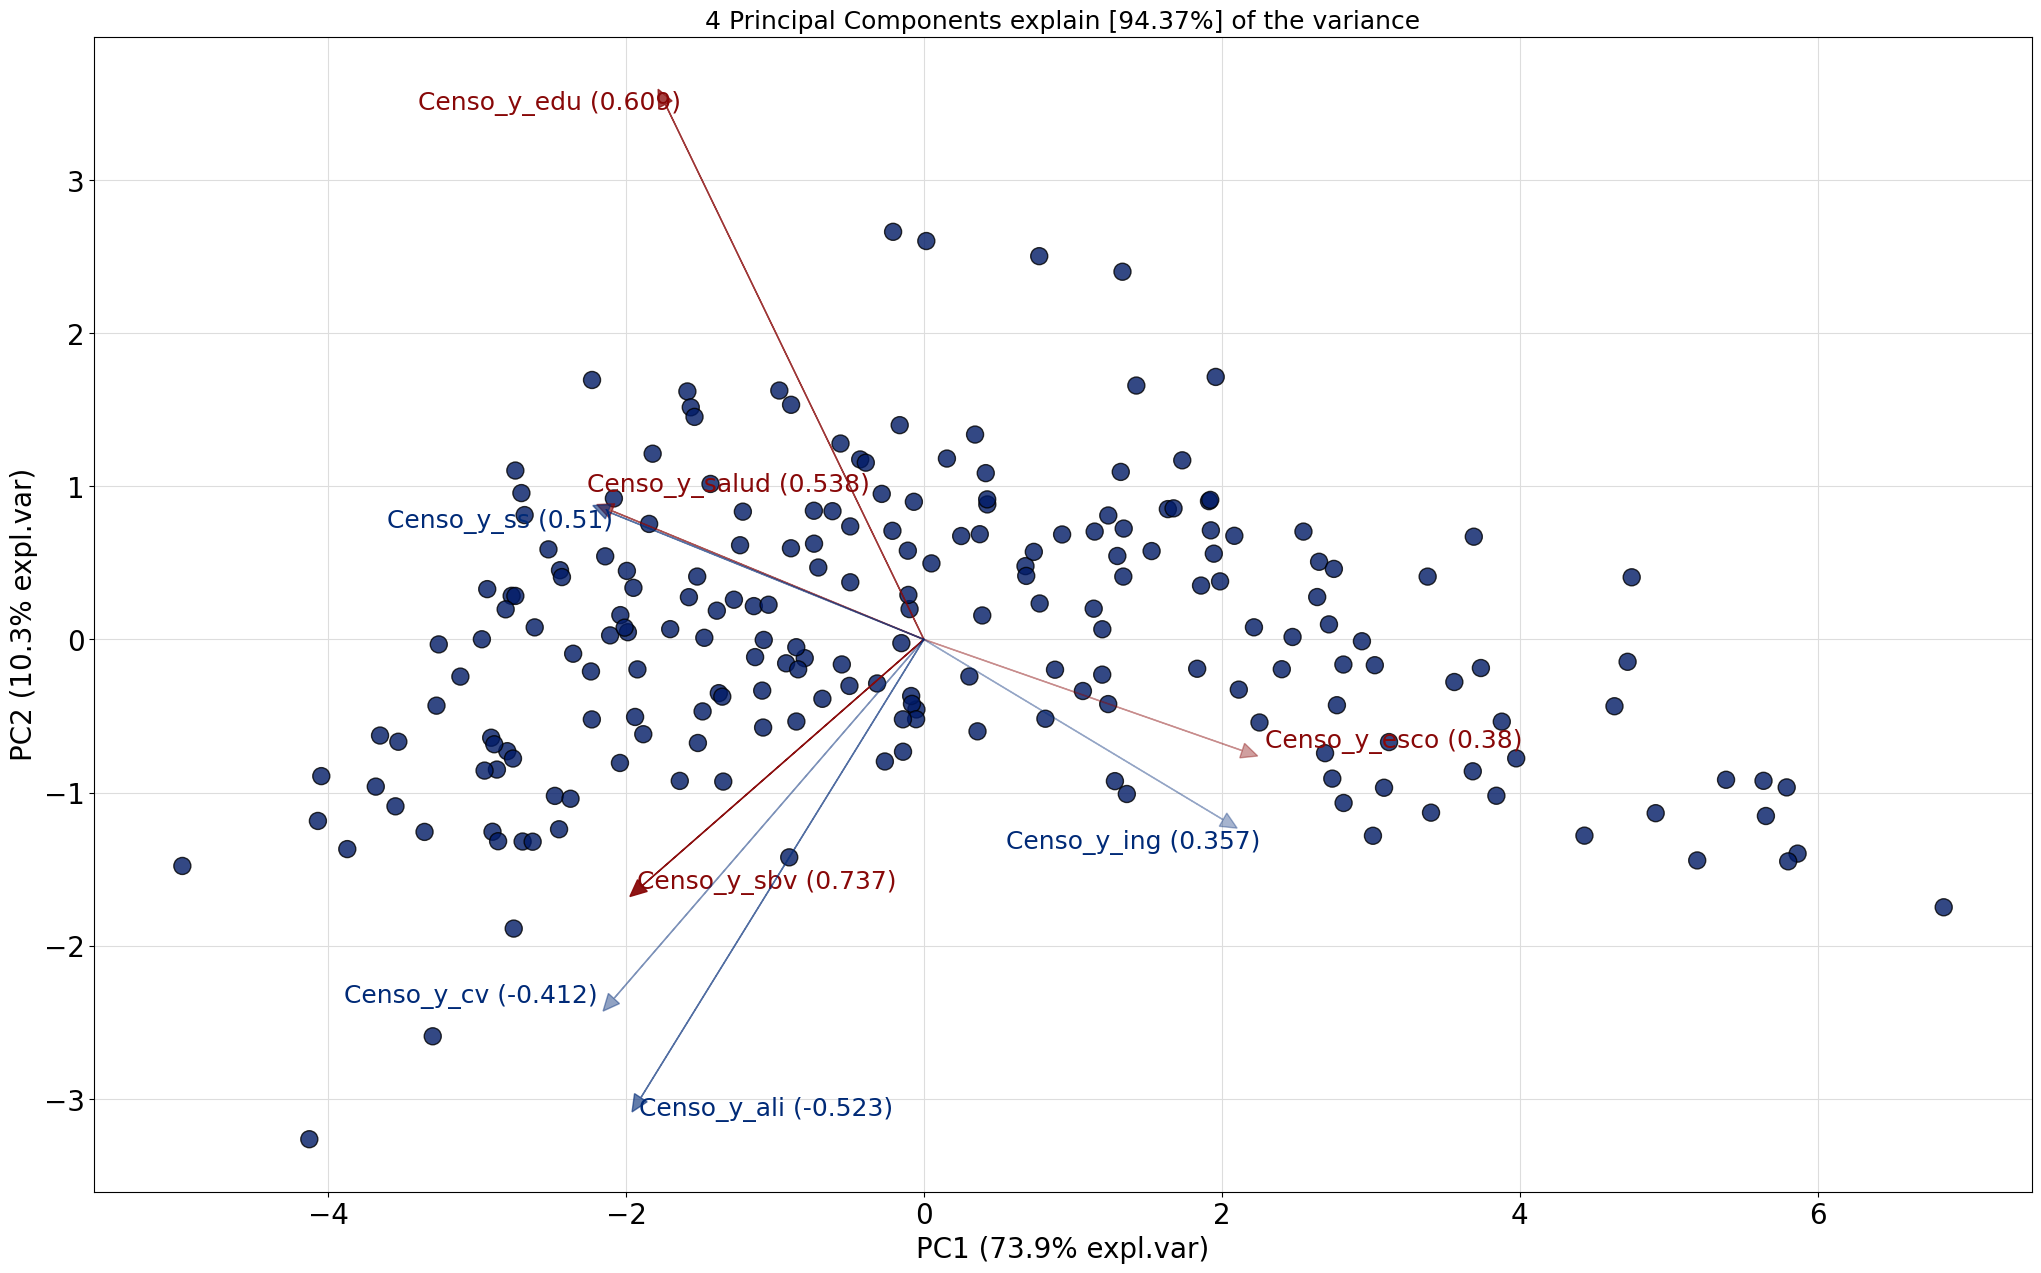

In [25]:
res=pca_model.fit_transform(X_norm)
# Greaficar el % de varianza explicado
fid, ax= pca_model.plot()

# Proyección de los individuos (municipios) en los 2 primeros componentes principales

fig, ax= pca_model.scatter(legend=False)

# Proyección de las variables en los 2 primeros componentes principales

fig_ax=pca_model.biplot(n_feat=8, legend=False, label=False)

# un biplot muestra tanto la proyección de los individuos como las direcciones y las variables
# originales en el espacio de los componentes principales.
# n_feat=8 indica que se desean mostrar 8 variables, legend = False que no se requiere etiqueta


In [ ]:
# interpretación de biplot.
# longitud de la Flecha: es proporcional a la importancia de la variable en el componente principal
# ángulo entre las flechas: nos mide la correlación entre variables.
# Flechas que estan cercanas, variables altamente correlacionadas
# Flechas perpendiculares indican variables no correlacionadas
# Flechas en direcciones opuestas indican una correlación negativa

# si una variable tiene un componente positivo en un eje principal y otro negativo en otro eje,
# significa que la variable contribuye de manera diferente en los componentes.

# El número en paréntesis es el coeficiente de correlación entre la columna  y el componente principal,
# cuantifica que tanto contribuye a ese coeficiente.
# Números cercanos a +1 o -1 significa que influyen de manera fuerte en el componente.

#Flechas que apuntan a un data cluster específico indica que la columna es influencial en definir la varianza dentro de 1 cluster.

#Significado

1. Censo_y_edu:  rezago educativo
2. Censo_y_salud:
3. Censo_y_ss:  acceso a seg social
4. Censo_y_cv:   calidad de la vivienda
5. Censo_y_sbv:   servicios básicos de la vivienda
6. Censo_y_ali:  alimentación
7. Censo_y_ing:   ingreso $
8. Censo_y_esco:   años escolaridad